# Level 1: 預測捐款金額 → 最大化 Operating Surplus

**策略**：EV = P(捐款) × E(金額|捐款)，篩選 EV > 邊際成本的人

- 訓練資料：`R1_TRAIN`（100K 筆，有 AmtThisYear）
- 評分資料：`R1_SCOREDATA`（100K 筆，無 Target，時間往後推一年）
- 輸出：只有 ID 欄位的 CSV，上傳排行榜

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, roc_auc_score, mean_absolute_error,
    mean_squared_error, r2_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

In [14]:
# ============================================================
# 1. 載入資料 & EDA
# ============================================================

def load_and_clean(path):
    """載入 CSV 並清理 BOM、空白、引號"""
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    # 數值欄位轉型
    num_cols = ['GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency',
                'Frequency', 'Seniority', 'TotalGift', 'MinGift', 'MaxGift',
                'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

train = load_and_clean('data/表格_FUNDRAISE_R1_TRAIN.csv')

print(f"訓練資料: {train.shape}")
print(f"\n目標變數:")
print(f"  捐款率: {train['GaveThisYear'].mean():.2%}")
print(f"  捐款者平均金額: ${train.loc[train['AmtThisYear'] > 0, 'AmtThisYear'].mean():.2f}")
print(f"  全體平均金額:   ${train['AmtThisYear'].mean():.2f}")
print(f"\n捐款金額分布 (捐款者):")
print(train.loc[train['AmtThisYear'] > 0, 'AmtThisYear'].describe())
train.head()

訓練資料: (100000, 21)

目標變數:
  捐款率: 18.05%
  捐款者平均金額: $65.21
  全體平均金額:   $11.77

捐款金額分布 (捐款者):
count    18050.000000
mean        65.210526
std        237.751736
min         10.000000
25%         20.000000
50%         25.000000
75%         50.000000
max      10000.000000
Name: AmtThisYear, dtype: float64


,GaveThisYear,ID,LastName,FirstName,Woman,Age,Salary,Education,City,SeniorList,...,Referrals,Recency,Frequency,Seniority,TotalGift,MinGift,MaxGift,GaveLastYear,AmtLastYear,AmtThisYear
0,0.0,2000001,ROMMES,RODNEY,0,25,107200,University / College,City,2,...,0,1,2,2,1010,10,1000,0,0,0
1,0.0,2000020,BAUTISTA,JACKIE,1,64,40700,High School,Suburban,10,...,2,3,3,6,770,20,500,1,20,0
2,1.0,2000029,MILLER,JOHN,0,49,73500,University / College,Downtown,6,...,0,4,1,4,90,90,90,0,0,20
3,0.0,2000038,NEECE,JORGE,0,54,42300,University / College,Suburban,7,...,2,5,1,5,20,20,20,0,0,0
4,0.0,2000041,JOHNSON,JOYCE,1,42,99000,University / College,Suburban,6,...,1,4,2,5,175,25,150,0,0,0


In [15]:
# ============================================================
# 2. 特徵工程 & 前處理
# ============================================================

DROP_COLS = ['ID', 'LastName', 'FirstName', 'AmtThisYear', 'GaveThisYear']
CAT_COLS = ['Education', 'City']

def preprocess(df, fit_dummies_cols=None):
    """前處理：移除非特徵欄位 → One-Hot Encoding"""
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    return out

train = train.dropna(subset=['GaveThisYear', 'AmtThisYear']).reset_index(drop=True)

X_all = preprocess(train)
y_cls = train['GaveThisYear'].astype(int)
y_amt = train['AmtThisYear']

feature_cols = X_all.columns.tolist()
print(f"有效樣本數: {len(train)}")
print(f"特徵數: {len(feature_cols)}")
print(f"特徵: {feature_cols}")

有效樣本數: 99951
特徵數: 19
特徵: ['Woman', 'Age', 'Salary', 'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency', 'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear', 'Education_High School', 'Education_University / College', 'City_Downtown', 'City_Rural', 'City_Suburban']


In [16]:
# ============================================================
# 3. 切分資料 & 訓練分類模型 P(GaveThisYear=1)
# ============================================================

X_train, X_val, y_cls_train, y_cls_val, y_amt_train, y_amt_val = train_test_split(
    X_all, y_cls, y_amt, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_val_sc = scaler_cls.transform(X_val)

clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf.fit(X_train_sc, y_cls_train)

y_proba_val = clf.predict_proba(X_val_sc)[:, 1]
y_pred_val = (y_proba_val >= 0.5).astype(int)
auc = roc_auc_score(y_cls_val, y_proba_val)

print(f"分類模型 AUC: {auc:.4f}")
print(classification_report(y_cls_val, y_pred_val, target_names=['未捐(0)', '有捐(1)']))

# 機率校準檢查
print("機率校準:")
for lo, hi in [(0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 1.0)]:
    mask = (y_proba_val >= lo) & (y_proba_val < hi)
    if mask.sum() > 0:
        print(f"  P∈[{lo:.1f},{hi:.1f}): n={mask.sum():>5}, 實際率={y_cls_val[mask].mean():.3f}")

分類模型 AUC: 0.6854
              precision    recall  f1-score   support

       未捐(0)       0.82      0.99      0.90     16383
       有捐(1)       0.56      0.04      0.07      3608

    accuracy                           0.82     19991
   macro avg       0.69      0.51      0.48     19991
weighted avg       0.78      0.82      0.75     19991

機率校準:
  P∈[0.0,0.1): n= 4218, 實際率=0.078
  P∈[0.1,0.2): n= 9281, 實際率=0.142
  P∈[0.2,0.3): n= 4014, 實際率=0.245
  P∈[0.3,0.5): n= 2253, 實際率=0.378
  P∈[0.5,0.7): n=  221, 實際率=0.561
  P∈[0.7,1.0): n=    4, 實際率=0.750


回歸模型 (僅捐款者, log 訓練):
  R² (log  space): 0.0179   ← 模型真正學到多少
  R² (orig space): -0.0165  ← 被極端值拉低，參考用
  MAE:  $47.42
  RMSE: $217.02
  捐款者數: train=14433, val=3608


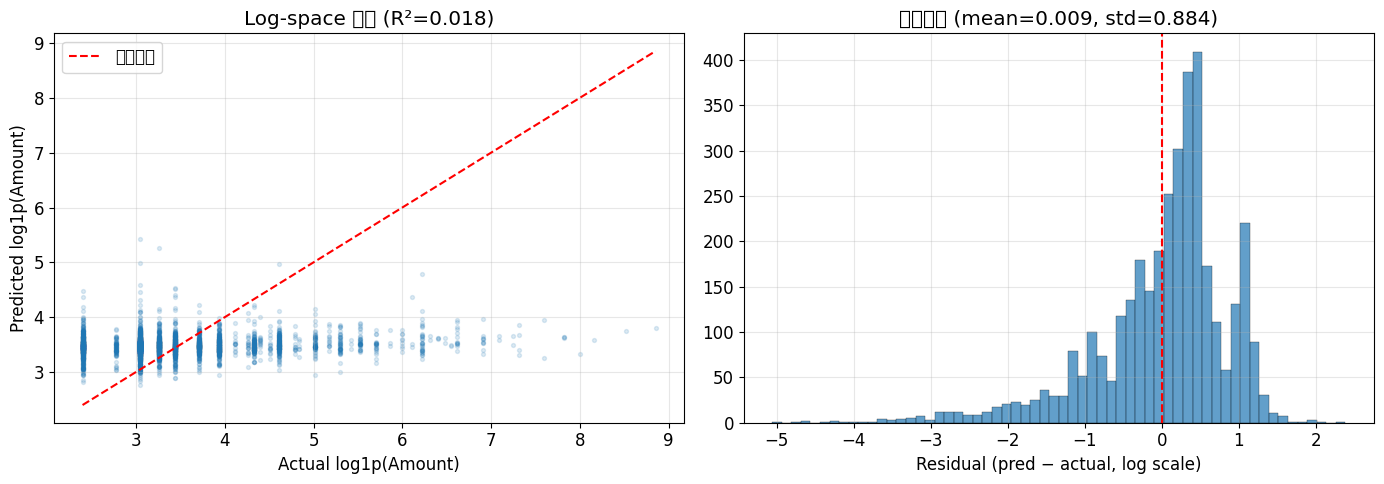

In [17]:
# ============================================================
# 4. 訓練回歸模型 E(AmtThisYear | GaveThisYear=1)
# ============================================================
# 只在捐款者上訓練，使用 log(1+y) 轉換處理右偏分布

donor_mask_train = y_amt_train > 0
donor_mask_val   = y_amt_val   > 0

X_donors_train   = X_train[donor_mask_train]
y_donors_train   = y_amt_train[donor_mask_train]
X_donors_val     = X_val[donor_mask_val]
y_donors_val     = y_amt_val[donor_mask_val]

scaler_reg = StandardScaler()
X_donors_train_sc = scaler_reg.fit_transform(X_donors_train)
X_donors_val_sc   = scaler_reg.transform(X_donors_val)

# 訓練目標：log1p(amount)
y_log_train = np.log1p(y_donors_train)
y_log_val   = np.log1p(y_donors_val)

reg = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
reg.fit(X_donors_train_sc, y_log_train)

y_pred_log = reg.predict(X_donors_val_sc)
y_pred_amt = np.expm1(y_pred_log).clip(min=0)

# ── 兩種尺度都評估 ──
mae  = mean_absolute_error(y_donors_val, y_pred_amt)
rmse = np.sqrt(mean_squared_error(y_donors_val, y_pred_amt))
r2_orig = r2_score(y_donors_val, y_pred_amt)
r2_log  = r2_score(y_log_val,   y_pred_log)

print(f"回歸模型 (僅捐款者, log 訓練):")
print(f"  R² (log  space): {r2_log:.4f}   ← 模型真正學到多少")
print(f"  R² (orig space): {r2_orig:.4f}  ← 被極端值拉低，參考用")
print(f"  MAE:  ${mae:.2f}")
print(f"  RMSE: ${rmse:.2f}")
print(f"  捐款者數: train={len(X_donors_train)}, val={len(X_donors_val)}")

# 預測 vs 實際 散佈圖（log space）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_log_val, y_pred_log, alpha=0.15, s=8)
lim = [y_log_val.min(), y_log_val.max()]
ax.plot(lim, lim, 'r--', lw=1.5, label='完美預測')
ax.set_xlabel('Actual log1p(Amount)')
ax.set_ylabel('Predicted log1p(Amount)')
ax.set_title(f'Log-space 預測 (R²={r2_log:.3f})')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
residuals = y_pred_log - y_log_val
ax.hist(residuals, bins=60, alpha=0.7, edgecolor='black', lw=0.3)
ax.axvline(0, color='red', ls='--')
ax.set_xlabel('Residual (pred − actual, log scale)')
ax.set_title(f'殘差分布 (mean={residuals.mean():.3f}, std={residuals.std():.3f})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# [實驗] E_amount 替代方案：AmtLastYear 代理
# ============================================================
# R²(log) = 0.0179 → 回歸模型幾乎無訊號
# 改用 AmtLastYear 作為 E_amount 代理，比較兩種 EV 的排序效果

DONOR_MEAN_AMT = train.loc[train['AmtThisYear'] > 0, 'AmtThisYear'].mean()

def estimate_amount_proxy(X_df, original_df):
    """有歷史捐款 → 用 AmtLastYear；否則用全體捐款者均值"""
    amt_last = original_df.loc[X_df.index, 'AmtLastYear'].values
    return np.where(amt_last > 0, amt_last, DONOR_MEAN_AMT)

# 驗證集上比較
E_reg   = np.expm1(reg.predict(X_val_sc)).clip(min=0)          # 原本回歸模型
E_proxy = estimate_amount_proxy(X_val, train)                   # AmtLastYear 代理
P_v     = clf.predict_proba(X_val_sc)[:, 1]

EV_reg   = P_v * E_reg
EV_proxy = P_v * E_proxy

# 排序一致性（Spearman 相關）
from scipy.stats import spearmanr
corr_reg,   _ = spearmanr(EV_reg,   y_amt_val)
corr_proxy, _ = spearmanr(EV_proxy, y_amt_val)
corr_between, _ = spearmanr(EV_reg, EV_proxy)

print(f"EV 排序 vs 實際捐款金額 (Spearman):")
print(f"  回歸模型 EV:    {corr_reg:.4f}")
print(f"  AmtLastYear EV: {corr_proxy:.4f}")
print(f"  兩者之間相關:   {corr_between:.4f}")
print(f"\n全體捐款者均值 (fallback): ${DONOR_MEAN_AMT:.2f}")

# Operating Surplus 比較（驗證集）
def surplus_from_ev(ev_arr, actual_amt, schedule):
    order = np.argsort(ev_arr)[::-1]
    amt_sorted = actual_amt.values[order]
    ev_sorted  = ev_arr[order]
    ranks = np.arange(1, len(ev_arr) + 1)
    marginal = np.array([get_marginal_cost(r, schedule) for r in ranks])
    cum_amt  = np.cumsum(amt_sorted)
    cum_cost = np.array([calc_total_cost(n, COST_SCHEDULE) for n in ranks])
    cum_surp = cum_amt - cum_cost
    mask = ev_sorted > marginal
    n_contact = mask.sum()
    surplus = cum_surp[n_contact - 1] if n_contact > 0 else 0
    return n_contact, surplus

n_reg,   s_reg   = surplus_from_ev(EV_reg,   y_amt_val, COST_SCHEDULE)
n_proxy, s_proxy = surplus_from_ev(EV_proxy, y_amt_val, COST_SCHEDULE)

print(f"\nOperating Surplus 比較 (驗證集):")
print(f"  回歸模型:       聯繫 {n_reg:,} 人, Surplus = ${s_reg:,.0f}")
print(f"  AmtLastYear:    聯繫 {n_proxy:,} 人, Surplus = ${s_proxy:,.0f}")

EV 排序 vs 實際捐款金額 (Spearman):
  回歸模型 EV:    0.2331
  AmtLastYear EV: 0.1713
  兩者之間相關:   0.7263

全體捐款者均值 (fallback): $65.21

Operating Surplus 比較 (驗證集):
  回歸模型:       聯繫 9,704 人, Surplus = $126,105
  AmtLastYear:    聯繫 17,153 人, Surplus = $123,640


驗證集 Operating Surplus 模擬:
  EV>成本策略: 聯繫 9482 人, Surplus = $125,930
  真實最佳:    聯繫 13965 人, Surplus = $140,270
  全部聯繫:    Surplus = $128,550
  策略效率:    89.8%


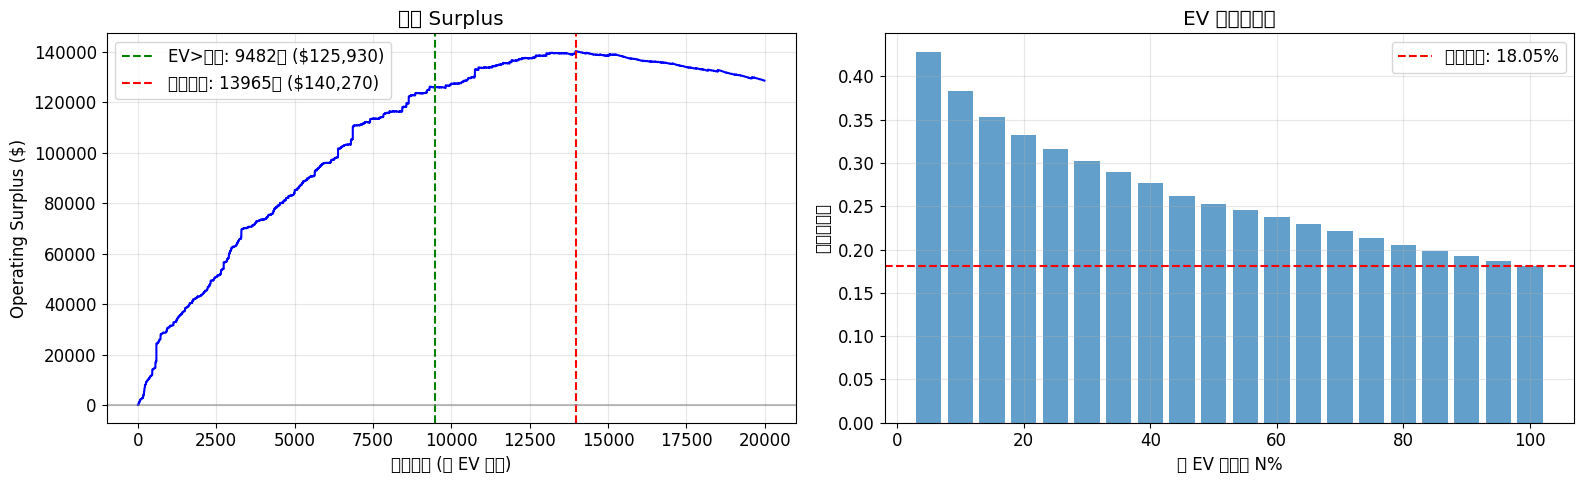

In [22]:
# ============================================================
# 5. 驗證集上計算 EV & 模擬 Operating Surplus
# ============================================================

# 成本結構 (⚠️ 請根據實際遊戲設定調整！)
COST_SCHEDULE = [
    (60_000, 5),     # 前 60,000 人每人 $5
    (np.inf, 25),    # 超過 60,000 人每人 $25
]

def calc_total_cost(n, schedule):
    """計算聯繫 n 人的總成本"""
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier
        prev = limit
    return total

def get_marginal_cost(rank, schedule):
    """第 rank 個人的邊際成本"""
    cumul = 0
    for limit, cost in schedule:
        if rank <= limit:
            return cost
        cumul = limit
    return schedule[-1][1]

# 對驗證集全體計算 EV
P_val = clf.predict_proba(X_val_sc)[:, 1]
E_val = np.expm1(reg.predict(scaler_reg.transform(X_val))).clip(min=0)
EV_val = P_val * E_val

val_df = pd.DataFrame({
    'EV': EV_val,
    'actual_amt': y_amt_val.values,
    'actual_gave': y_cls_val.values,
}).sort_values('EV', ascending=False).reset_index(drop=True)

val_df['rank'] = range(1, len(val_df) + 1)
val_df['cum_donation'] = val_df['actual_amt'].cumsum()
val_df['cum_cost'] = val_df['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
val_df['cum_surplus'] = val_df['cum_donation'] - val_df['cum_cost']

# 最佳切點 & 我們的策略切點
best_n = val_df['cum_surplus'].idxmax() + 1
best_surplus = val_df['cum_surplus'].max()

# EV > marginal cost 策略
val_df['marginal_cost'] = val_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
our_n = (val_df['EV'] > val_df['marginal_cost']).sum()
our_surplus = val_df.loc[our_n - 1, 'cum_surplus'] if our_n > 0 else 0

print(f"驗證集 Operating Surplus 模擬:")
print(f"  EV>成本策略: 聯繫 {our_n} 人, Surplus = ${our_surplus:,.0f}")
print(f"  真實最佳:    聯繫 {best_n} 人, Surplus = ${best_surplus:,.0f}")
print(f"  全部聯繫:    Surplus = ${val_df['cum_surplus'].iloc[-1]:,.0f}")
print(f"  策略效率:    {our_surplus/best_surplus:.1%}" if best_surplus > 0 else "")

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.plot(val_df['rank'], val_df['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n, color='green', ls='--', label=f'EV>成本: {our_n}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red', ls='--', label=f'真實最佳: {best_n}人 (${best_surplus:,.0f})')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數 (按 EV 降序)')
ax.set_ylabel('Operating Surplus ($)')
ax.set_title('累積 Surplus')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
pcts = np.arange(5, 105, 5)
rates = [val_df.iloc[:int(len(val_df)*p/100)]['actual_gave'].mean() for p in pcts]
ax.bar(pcts, rates, width=4, alpha=0.7)
ax.axhline(y_cls_val.mean(), color='r', ls='--', label=f'全體平均: {y_cls_val.mean():.2%}')
ax.set_xlabel('按 EV 排序前 N%')
ax.set_ylabel('實際捐款率')
ax.set_title('EV 排序有效性')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# 6. 用全部訓練資料重新訓練 → 對 R1_SCOREDATA 評分
# ============================================================

# 用全部訓練資料重新訓練（不留驗證集，最大化訓練量）
scaler_cls_full = StandardScaler()
X_all_sc = scaler_cls_full.fit_transform(X_all)

clf_full = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf_full.fit(X_all_sc, y_cls)
print("分類模型（全資料）訓練完成")

# 回歸模型也用全部捐款者重新訓練
donor_mask_all = y_amt > 0
X_donors_all = X_all[donor_mask_all]
y_donors_all = y_amt[donor_mask_all]

scaler_reg_full = StandardScaler()
X_donors_all_sc = scaler_reg_full.fit_transform(X_donors_all)

reg_full = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
reg_full.fit(X_donors_all_sc, np.log1p(y_donors_all))
print(f"回歸模型（全資料）訓練完成，捐款者: {len(X_donors_all)}")

# --- 載入 SCOREDATA ---
score_raw = load_and_clean('data/表格_FUNDRAISE_R1_SCOREDATA.csv')
print(f"\nScoreData 形狀: {score_raw.shape}")
print(f"ScoreData 欄位: {score_raw.columns.tolist()}")

score_ids = score_raw['ID'].copy()
X_score = preprocess(score_raw)

# 確保欄位對齊
for col in feature_cols:
    if col not in X_score.columns:
        X_score[col] = 0
X_score = X_score[feature_cols]

# Scoring
P_score = clf_full.predict_proba(scaler_cls_full.transform(X_score))[:, 1]
E_score = np.expm1(reg_full.predict(scaler_reg_full.transform(X_score))).clip(min=0)
EV_score = P_score * E_score

score_df = pd.DataFrame({
    'ID': score_ids.values,
    'P_gave': P_score,
    'E_amount': E_score,
    'EV': EV_score,
}).sort_values('EV', ascending=False).reset_index(drop=True)

score_df['rank'] = range(1, len(score_df) + 1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

print(f"\n評分完成！EV 統計:")
print(f"  平均: ${EV_score.mean():.2f}")
print(f"  中位: ${np.median(EV_score):.2f}")
print(f"  最大: ${EV_score.max():.2f}")
print(f"  EV > $5 (成本) 的人數: {(EV_score > 5).sum()}")
print(f"  EV > $25 的人數:       {(EV_score > 25).sum()}")

分類模型（全資料）訓練完成
回歸模型（全資料）訓練完成，捐款者: 18041

ScoreData 形狀: (100000, 19)
ScoreData 欄位: ['ID', 'LastName', 'FirstName', 'Woman', 'Age', 'Salary', 'Education', 'City', 'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency', 'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']

評分完成！EV 統計:
  平均: $6.25
  中位: $4.98
  最大: $21802.81
  EV > $5 (成本) 的人數: 49700
  EV > $25 的人數:       255


聯繫名單:
  總人數:     100000
  聯繫人數:   49700
  聯繫比例:   49.7%
  預估成本:   $248,500
  EV 門檻:    $5.00


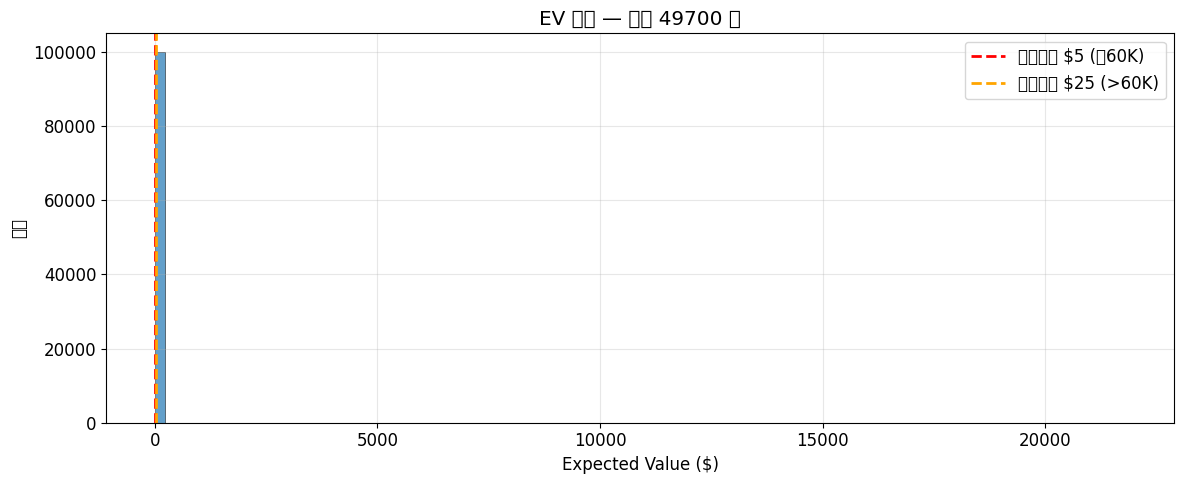


已匯出 49700 個 ID 到 output/level1_contact_list.csv
前 10 筆:
     ID   P_gave     E_amount           EV
2420891 0.731312 29813.278308 21802.814026
2474554 0.403852   642.675695   259.545802
2326946 0.572206   435.993925   249.478426
2616098 0.188753  1289.312922   243.361726
2355599 0.276112   852.022838   235.254114
2139650 0.273613   742.985209   203.290502
2414936 0.504730   364.289031   183.867758
2477697 0.120649  1475.341604   177.998285
2655021 0.482288   367.270578   177.130098
2682382 0.503104   322.771932   162.387994


In [24]:
# ============================================================
# 7. 篩選聯繫名單 & 匯出 CSV
# ============================================================

# 篩選 EV > 邊際成本
contact = score_df[score_df['EV'] > score_df['marginal_cost']].copy()

print(f"聯繫名單:")
print(f"  總人數:     {len(score_df)}")
print(f"  聯繫人數:   {len(contact)}")
print(f"  聯繫比例:   {len(contact)/len(score_df):.1%}")
print(f"  預估成本:   ${calc_total_cost(len(contact), COST_SCHEDULE):,.0f}")
print(f"  EV 門檻:    ${contact['EV'].min():.2f}")

# EV 分布
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(score_df['EV'], bins=100, alpha=0.7, edgecolor='black', lw=0.5)
ax.axvline(5, color='red', ls='--', lw=2, label=f'成本門檻 $5 (前60K)')
ax.axvline(25, color='orange', ls='--', lw=2, label=f'成本門檻 $25 (>60K)')
ax.set_xlabel('Expected Value ($)')
ax.set_ylabel('人數')
ax.set_title(f'EV 分布 — 聯繫 {len(contact)} 人')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 匯出 ---
output_path = 'output/level1_contact_list.csv'
import os
os.makedirs('output', exist_ok=True)
contact[['ID']].to_csv(output_path, index=False)
print(f"\n已匯出 {len(contact)} 個 ID 到 {output_path}")
print(f"前 10 筆:")
print(contact[['ID', 'P_gave', 'E_amount', 'EV']].head(10).to_string(index=False))

In [25]:
# ============================================================
# [實驗] Top N% 策略 vs EV > 門檻策略
# ============================================================
# 驗證集最佳切點 = 13,965 人 ≈ 14.0% of train
# 把這個比例套到 SCOREDATA（100K 人）

TOP_FRAC = val_df['cum_surplus'].idxmax() / len(val_df)  # 驗證集最佳比例
n_topn   = int(TOP_FRAC * len(score_df))

contact_topn = score_df.head(n_topn).copy()

# 兩種策略的預估成本
n_ev    = len(contact)       # 原本 EV > 門檻
cost_ev   = calc_total_cost(n_ev,   COST_SCHEDULE)
cost_topn = calc_total_cost(n_topn, COST_SCHEDULE)

print(f"驗證集最佳比例: {TOP_FRAC:.2%}  ({val_df['cum_surplus'].idxmax()+1:,} / {len(val_df):,})")
print()
print(f"{'策略':<20} {'聯繫人數':>10} {'預估成本':>12}")
print("-" * 45)
print(f"{'EV > 門檻':<20} {n_ev:>10,}  ${cost_ev:>10,.0f}")
print(f"{'Top N%':<20} {n_topn:>10,}  ${cost_topn:>10,.0f}")
print()

# 匯出 Top N% 版本
output_topn = 'output/level1_topn_contact_list.csv'
contact_topn[['ID']].to_csv(output_topn, index=False)
print(f"已匯出 Top N% 名單：{n_topn:,} 人 → {output_topn}")
print(f"已匯出 EV 門檻名單：{n_ev:,} 人 → output/level1_contact_list.csv")
print()
print("建議上傳 Top N% 版本（更接近驗證集最佳切點）")

驗證集最佳比例: 69.85%  (13,965 / 19,991)

策略                         聯繫人數         預估成本
---------------------------------------------
EV > 門檻                  49,700  $   248,500
Top N%                   69,851  $   546,275

已匯出 Top N% 名單：69,851 人 → output/level1_topn_contact_list.csv
已匯出 EV 門檻名單：49,700 人 → output/level1_contact_list.csv

建議上傳 Top N% 版本（更接近驗證集最佳切點）
